# Part 2 – Machine Learning: Regression and Classification

This notebook builds regression and classification models using the cleaned student performance dataset created in Part 1.
It includes preprocessing, feature engineering, regression modelling, logistic regression, evaluation metrics, ROC analysis, threshold tuning and bootstrap validation.

## 1. Import Required Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## 2. Load the Clean Dataset

In [3]:
df = pd.read_csv("../data/cleaned_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Dataset Inspection

In [4]:
print("Shape:", df.shape)

display(df.head())

display(df.info())

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

None

## 4. Create the Classification Target

The dataset contains the final grade (G3) as a continuous variable. For classification tasks, a new binary target variable named "Pass" is created.

Pass (1): G3 ≥ 10
Fail (0): G3 < 10

In [5]:
# Create Pass/Fail target

df["Pass"] = (df["G3"] >= 10).astype(int)

print("Pass/Fail target created successfully!")

display(df[["G3", "Pass"]].head())

Pass/Fail target created successfully!


,G3,Pass
0,11,1
1,11,1
2,12,1
3,14,1
4,13,1


## 5. Check Class Distribution

Class Distribution
Pass
1    549
0    100
Name: count, dtype: int64


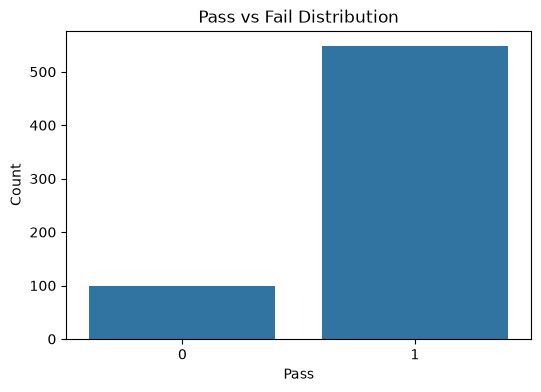

In [6]:
class_counts = df["Pass"].value_counts()

print("Class Distribution")
print(class_counts)

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Pass vs Fail Distribution")
plt.xlabel("Pass")
plt.ylabel("Count")

plt.show()

## 6. Feature Selection

Regression Target - G3 (Final Grade)
Classification Target - Pass (Pass/Fail)

Separate feature matrices and target variables are created for the regression and classification models.

In [15]:
# Regression

X_reg = df.drop(columns=["G3", "Pass"])
y_reg = df["G3"]

# Classification

X_clf = df.drop(columns=["G3", "Pass"])
y_clf = df["Pass"]

print("Regression Features :", X_reg.shape)
print("Regression Target   :", y_reg.shape)

print("Classification Features :", X_clf.shape)
print("Classification Target   :", y_clf.shape)

Regression Features : (649, 32)
Regression Target   : (649,)
Classification Features : (649, 32)
Classification Target   : (649,)


## 7. Encode Categorical Features

Categorical variables are converted into numerical representations using One-Hot Encoding.
The first category is dropped to avoid multicollinearity.

In [16]:
# Convert categorical columns into dummy variables

X_reg = pd.get_dummies(X_reg, drop_first=True)
X_clf = pd.get_dummies(X_clf, drop_first=True)

print("Regression Feature Shape :", X_reg.shape)
print("Classification Feature Shape :", X_clf.shape)

Regression Feature Shape : (649, 41)
Classification Feature Shape : (649, 41)


In [31]:
print(X_clf.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


## 8. Train-Test Split

The dataset is divided into training (80%) and testing (20%) sets.

In [17]:
from sklearn.model_selection import train_test_split

# Regression

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Regression")
print(X_reg_train.shape, X_reg_test.shape)

print("Classification")
print(X_clf_train.shape, X_clf_test.shape)

Regression
(519, 41) (130, 41)
Classification
(519, 41) (130, 41)


## 9. Feature Scaling

StandardScaler is applied to normalize the feature values.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

scaler_clf = StandardScaler()

X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled = scaler_clf.transform(X_clf_test)

print("Scaling completed successfully!")

Scaling completed successfully!


## 9. Linear Regression Model

A Linear Regression model is trained to predict the student's final grade (G3).

The model is evaluated using below,
Mean Squared Error (MSE)
R² Score

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_reg_train_scaled, y_reg_train)

# Predictions
y_pred_linear = linear_model.predict(X_reg_test_scaled)

# Evaluation
linear_mse = mean_squared_error(y_reg_test, y_pred_linear)
linear_r2 = r2_score(y_reg_test, y_pred_linear)

print("Linear Regression Results")
print(f"MSE      : {linear_mse:.3f}")
print(f"R² Score : {linear_r2:.3f}")

Linear Regression Results
MSE      : 1.476
R² Score : 0.849


## 10. Ridge Regression

To reduce overfitting by applying L2 regularization.

In [20]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_reg_train_scaled, y_reg_train)

y_pred_ridge = ridge_model.predict(X_reg_test_scaled)

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"MSE      : {ridge_mse:.3f}")
print(f"R² Score : {ridge_r2:.3f}")

Ridge Regression Results
------------------------
MSE      : 1.476
R² Score : 0.849


## 11. Regression Model Comparison

In [21]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [linear_mse, ridge_mse],
    "R2 Score": [linear_r2, ridge_r2]
})

display(comparison)

,Model,MSE,R2 Score
0,Linear Regression,1.475909,0.848651
1,Ridge Regression,1.475518,0.848691


## 12. Regression Coefficients

This is to indicate how each feature influences the predicted final grade while keeping other variables constant.

In [22]:
coefficients = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

display(coefficients.head(15))

,Feature,Coefficient
14,G2,2.471735
13,G1,0.460262
26,Fjob_services,-0.240538
1,Medu,-0.166254
25,Fjob_other,-0.163351
15,school_MS,-0.145509
29,reason_other,-0.128880
5,failures,-0.124303
7,freetime,-0.113908
27,Fjob_teacher,-0.107944


## 13. Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

# Create model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train
logistic_model.fit(
    X_clf_train_scaled,
    y_clf_train
)

# Predictions
y_pred = logistic_model.predict(X_clf_test_scaled)

# Prediction probabilities
y_prob = logistic_model.predict_proba(X_clf_test_scaled)[:,1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## 14. Confusion Matrix

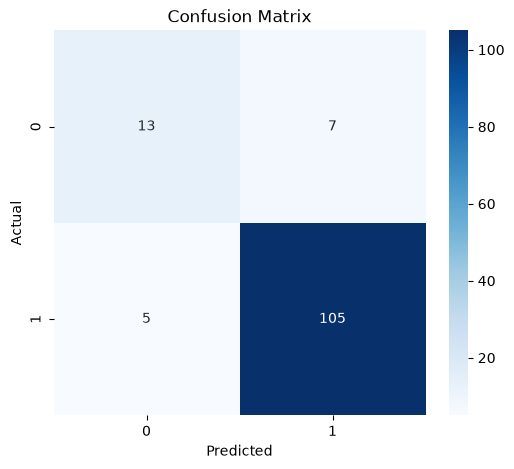

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_clf_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 15. Classification Report

In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_clf_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.94      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.83      0.80      0.82       130
weighted avg       0.90      0.91      0.91       130



## 16. ROC Curve and AUC

ROC-AUC Score : 0.9064


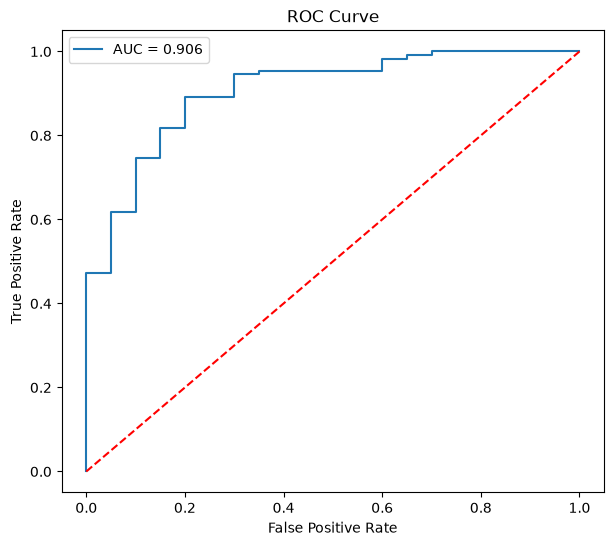

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_prob
)

auc_score = roc_auc_score(
    y_clf_test,
    y_prob
)

print(f"ROC-AUC Score : {auc_score:.4f}")

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## 17. Logistic Regression Feature Coefficients

In [27]:
coef_df = pd.DataFrame({
    "Feature": X_clf.columns,
    "Coefficient": logistic_model.coef_[0]
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute",
    ascending=False
)

display(coef_df.head(15))

,Feature,Coefficient,Absolute
14,G2,2.893321,2.893321
13,G1,2.037623,2.037623
15,school_MS,-0.831465,0.831465
25,Fjob_other,-0.752502,0.752502
26,Fjob_services,-0.710967,0.710967
0,age,0.702182,0.702182
20,Mjob_health,0.483467,0.483467
5,failures,-0.450700,0.450700
40,romantic_yes,-0.409986,0.409986
2,Fedu,-0.393414,0.393414


## 18. Threshold Comparison

In [28]:
from sklearn.metrics import accuracy_score

thresholds = [0.30, 0.50, 0.70]

results = []

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(
        y_clf_test,
        predictions
    )

    results.append([threshold, accuracy])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy"
    ]
)

display(threshold_df)

,Threshold,Accuracy
0,0.3,0.869231
1,0.5,0.907692
2,0.7,0.876923


## 19. Bootstrap Validation

In [29]:
from sklearn.utils import resample

bootstrap_scores = []

for i in range(100):

    X_sample, y_sample = resample(
        X_clf_test_scaled,
        y_clf_test,
        replace=True,
        random_state=i
    )

    predictions = logistic_model.predict(X_sample)

    score = accuracy_score(
        y_sample,
        predictions
    )

    bootstrap_scores.append(score)

print(f"Mean Bootstrap Accuracy : {np.mean(bootstrap_scores):.4f}")
print(f"Standard Deviation      : {np.std(bootstrap_scores):.4f}")

Mean Bootstrap Accuracy : 0.9108
Standard Deviation      : 0.0257


## 20. Save Models

In [30]:
import joblib

joblib.dump(
    linear_model,
    "../output/linear_regression.pkl"
)

joblib.dump(
    ridge_model,
    "../output/ridge_regression.pkl"
)

joblib.dump(
    logistic_model,
    "../output/logistic_regression.pkl"
)

print("Models saved successfully!")

Models saved successfully!
